# Antisense transcription calling
June 9, 2025

Examine the non-sense transcription for various windows of the genome to motivate the need/procedure for calling non-sense transcripts that may be cell cycle-regulated.


In [1]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [216]:
from src.sgd import read_sgd_genes, read_nondubious_genes_dataset, load_origins_sgd
from src.orf_plotter import load_default_orf_plotter

orf_plotter = load_default_orf_plotter()


In [259]:
chrom = 16

In [420]:
# Load the RNA_seq for chromosome 1, and compute pileup for plotting
from src.timer import Timer
from src.read_bam import read_rna_bam, get_rna_seq_filepaths_df

rna_filepaths_df = get_rna_seq_filepaths_df().set_index(['replicate', 'time'])

def load_all_chrom_reads(rna_filepaths_df, replicate, chrom):
    timer = Timer()

    # Load the first time point
    all_chrom_reads_arr = []
    i = 0
    replicate_filepaths = rna_filepaths_df.loc[replicate]
    for timepoint, row in replicate_filepaths.iterrows():
        time_rna_reads = read_rna_bam(row.full_path)
        single_chrom_reads = time_rna_reads[time_rna_reads['chr'] == chrom].copy()
        single_chrom_reads['sample'] = timepoint
        all_chrom_reads_arr.append(single_chrom_reads)
        timer.print_time(f"{i}/{len(replicate_filepaths)}")
        i += 1

        # Conserve memory
        del time_rna_reads

    all_chrom_reads = pd.concat(all_chrom_reads_arr)
    return all_chrom_reads

all_chrom_reads_rep2 = load_all_chrom_reads(rna_filepaths_df, 2, chrom)
all_chrom_reads_rep1 = load_all_chrom_reads(rna_filepaths_df, 1, chrom)

0/14 - 00:01:21.234
1/14 - 00:02:20.266
2/14 - 00:03:45.623
3/14 - 00:04:58.029
4/14 - 00:06:09.859
5/14 - 00:07:31.383
6/14 - 00:08:12.973
7/14 - 00:10:22.747
8/14 - 00:11:34.499
9/14 - 00:12:58.773
10/14 - 00:14:32.843
11/14 - 00:16:02.392
12/14 - 00:17:30.929
13/14 - 00:19:00.060


In [426]:
from src.global_config import GlobalConstants

def compute_pileups(all_chrom_reads, span, replicate):
    
    within_span_reads = all_chrom_reads[(all_chrom_reads['start'] < span[1]) & 
                                    (all_chrom_reads['stop'] > span[0])]

    bins = np.linspace(span[0], span[1], 1000)

    if replicate == 1:
        timepoints = GlobalConstants.EXPRESSION_WT1_TIMEPOINTS
    else:
        timepoints = GlobalConstants.EXPRESSION_WT2_TIMEPOINTS

    all_watson_pileups_per_time = []
    all_crick_pileups_per_time = []

    for time in timepoints:
        timepoint_reads = within_span_reads[within_span_reads['sample'] == time]
        watson_reads = timepoint_reads[timepoint_reads.strand == '+']
        crick_reads = timepoint_reads[timepoint_reads.strand == '-']

        watson_counts, bin_boundaries = np.histogram(watson_reads['start'], bins=bins)
        watson_df = pd.DataFrame(watson_counts).T
        watson_df.index = [time]

        crick_counts, bin_boundaries = np.histogram(crick_reads['start'], bins=bins)
        crick_df = pd.DataFrame(crick_counts).T
        crick_df.index = [time]

        all_watson_pileups_per_time.append(watson_df)
        all_crick_pileups_per_time.append(crick_df)

    watson_pileups_df = pd.concat(all_watson_pileups_per_time)
    crick_pileups_df = pd.concat(all_crick_pileups_per_time)
    
    return watson_pileups_df, crick_pileups_df, bin_boundaries

In [534]:
def plot_rna_at_region(span, chrom, all_chrom_reads, replicate):
    orf_plotter.set_span_chrom(span, chrom)
    
    watson_pileups_df, crick_pileups_df, bin_boundaries = \
        compute_pileups(all_chrom_reads, span, replicate)
    
    from scipy.stats.distributions import norm

    # Smoothing kernel
    xs = np.linspace(-5, 5, 10)
    kernel = norm.pdf(xs, 0, 1)
    kernel = kernel/kernel.max()

    plt.figure(figsize=(18, 2))
    plt.subplot(2, 1, 1)
    ax = plt.gca()
    orf_plotter.plot_orf_annotations(ax)

    plt.subplot(2, 1, 2)

    moving_avg_kernel = np.ones(6)/6
    
    if replicate == 1:
        timepoints = GlobalConstants.EXPRESSION_WT1_TIMEPOINTS
    else:
        timepoints = GlobalConstants.EXPRESSION_WT2_TIMEPOINTS
        
    for i, time in enumerate(timepoints):
        w_time_pileups = watson_pileups_df.loc[time]
        c_time_pileups = crick_pileups_df.loc[time]

        w_time_pileups = np.convolve(w_time_pileups, kernel, mode='same')
        c_time_pileups = np.convolve(c_time_pileups, kernel, mode='same')

        plt.plot(bin_boundaries[:-1], np.log2(w_time_pileups+1), 
                 c=plt.cm.Blues(i/len(timepoints)), lw=0.5)
        plt.plot(bin_boundaries[:-1], -np.log2(c_time_pileups+1), 
                 c=plt.cm.Reds(i/len(timepoints)), lw=0.5)

    plt.xlim(span[0], span[1])
    plt.axhline(0, c='black', lw=1, zorder=0)
    plt.ylim(-17, 17)

In [535]:
clb5_div_antisense_span = selection_span

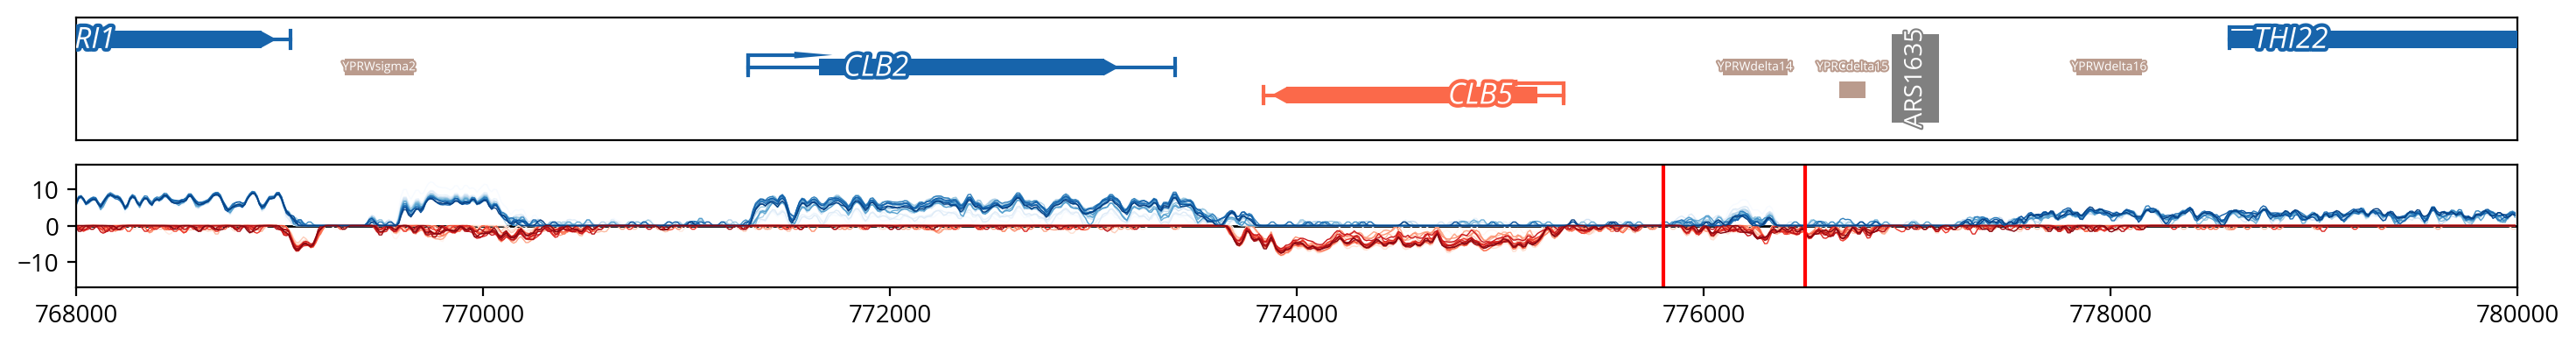

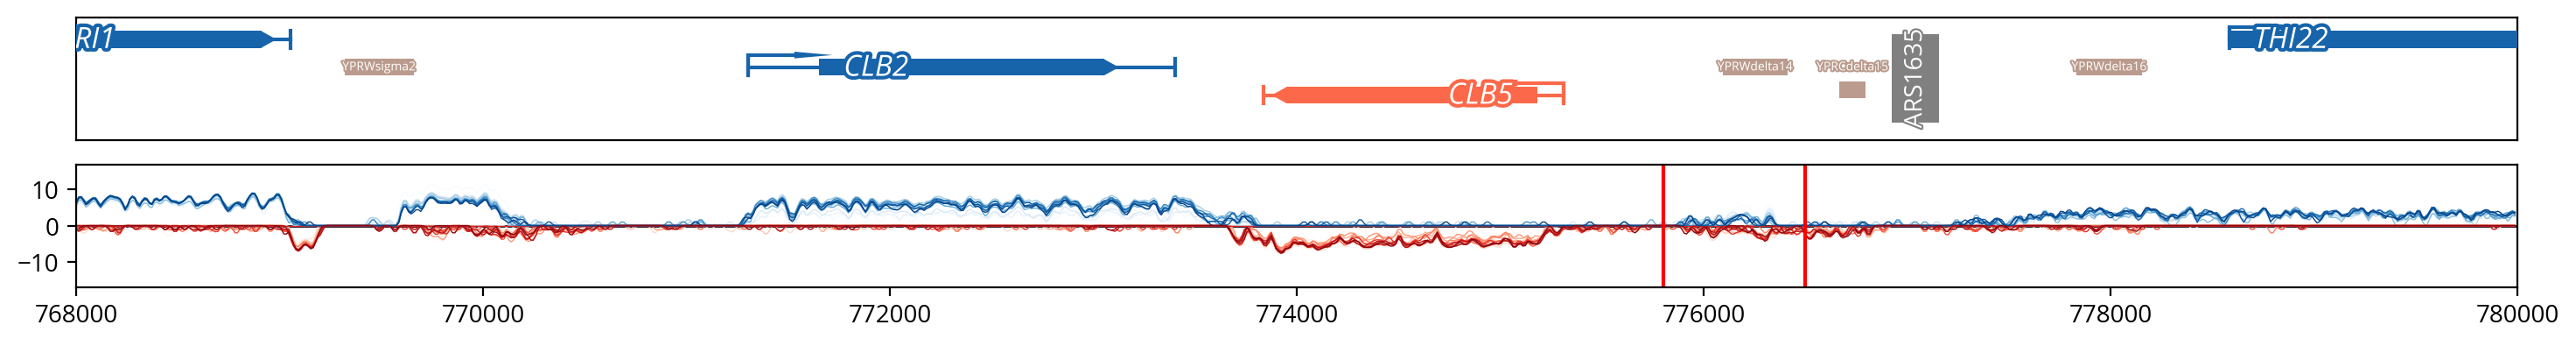

In [536]:
chrom = 16
span = 768000, 780000

plot_rna_at_region(span, chrom, all_chrom_reads_rep1, replicate=1)

for s in clb5_div_antisense_span:
    plt.axvline(s, c='red')

plot_rna_at_region(span, chrom, all_chrom_reads_rep2, replicate=2)

for s in clb5_div_antisense_span:
    plt.axvline(s, c='red')

In [422]:
chrom_total_counts_rep1 = all_chrom_reads_rep1.groupby('sample').count()
chrom_total_counts_rep1 = chrom_total_counts_rep1[['stop']].rename(columns={'stop': 'count'})

chrom_total_counts_rep2 = all_chrom_reads_rep2.groupby('sample').count()
chrom_total_counts_rep2 = chrom_total_counts_rep2[['stop']].rename(columns={'stop': 'count'})

In [424]:
rna_norm_scalar1 = chrom_total_counts_rep1.max() /  chrom_total_counts_rep1
rna_norm_scalar2 = chrom_total_counts_rep2.max() /  chrom_total_counts_rep2
# chrom_total_counts * rna_norm_scalar

In [427]:
timepoints1 = GlobalConstants.EXPRESSION_WT1_TIMEPOINTS
timepoints2 = GlobalConstants.EXPRESSION_WT2_TIMEPOINTS

In [537]:
def select_and_normalize_reads(all_chrom_reads_rep1, all_chrom_reads_rep2, selection_span,
                              strand):
    selected_reads1 = all_chrom_reads_rep1[(all_chrom_reads_rep1.stop > selection_span[0]) & 
                                     (all_chrom_reads_rep1.start < selection_span[1]) & 
                                     (all_chrom_reads_rep1.strand == strand)]

    selected_reads2 = all_chrom_reads_rep2[(all_chrom_reads_rep2.stop > selection_span[0]) & 
                                     (all_chrom_reads_rep2.start < selection_span[1]) & 
                                     (all_chrom_reads_rep2.strand == strand)]

    # Normalize by the total reads of the chromosome
    normed_selected_reads1 = selected_reads1.groupby('sample').count().stop.values*\
        rna_norm_scalar1.values.flatten()

    normed_selected_reads2 = selected_reads2.groupby('sample').count().stop.values*\
        rna_norm_scalar2.values.flatten()
    return normed_selected_reads1, normed_selected_reads2

In [541]:
normed_selected_reads1_w, normed_selected_reads2_w = \
    select_and_normalize_reads(all_chrom_reads_rep1,
    all_chrom_reads_rep2,
    selection_span,
    '+')

normed_selected_reads1_c, normed_selected_reads2_c = \
    select_and_normalize_reads(all_chrom_reads_rep1,
    all_chrom_reads_rep2,
    selection_span,
    '-')

(0.0, 11.0)

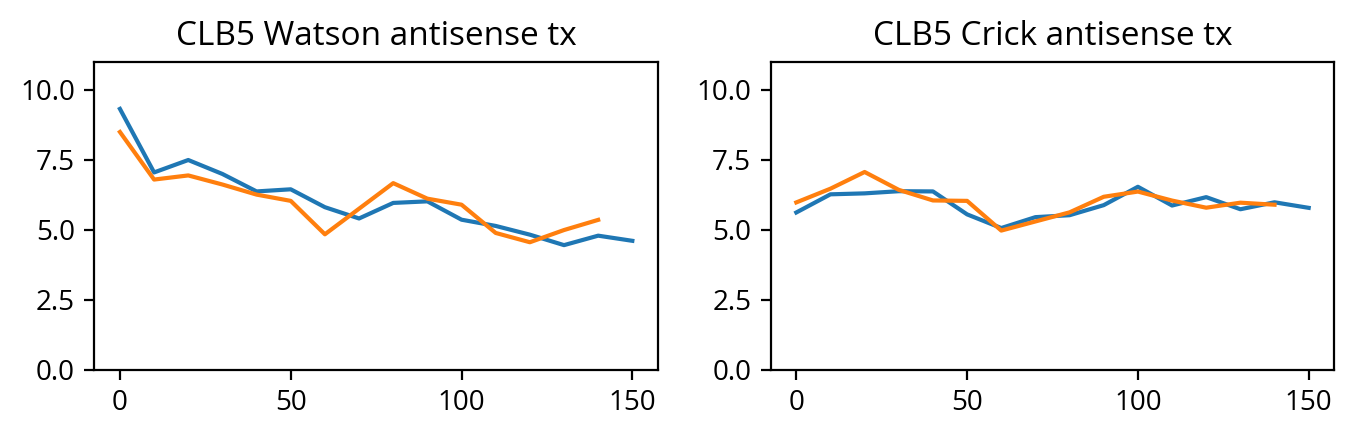

In [544]:
plt.figure(figsize=(8, 2))
plt.subplot(1, 2, 1)
plt.plot(timepoints1, np.log2(normed_selected_reads1_w+1))
plt.plot(timepoints2, np.log2(normed_selected_reads2_w+1))
plt.title("CLB5 Watson antisense tx")
plt.ylim(0, 11)

plt.subplot(1, 2, 2)
plt.plot(timepoints1, np.log2(normed_selected_reads1_c+1))
plt.plot(timepoints2, np.log2(normed_selected_reads2_c+1))
plt.title("CLB5 Crick antisense tx")
plt.ylim(0, 11)

In [432]:
from pipeline.CombinedDeconvolveGeneExpressionRunner import CombinedDeconvolveGeneExpressionRunner
output_directory = 'output/draft3_run/'
expression_deconv_runner = CombinedDeconvolveGeneExpressionRunner(output_directory)

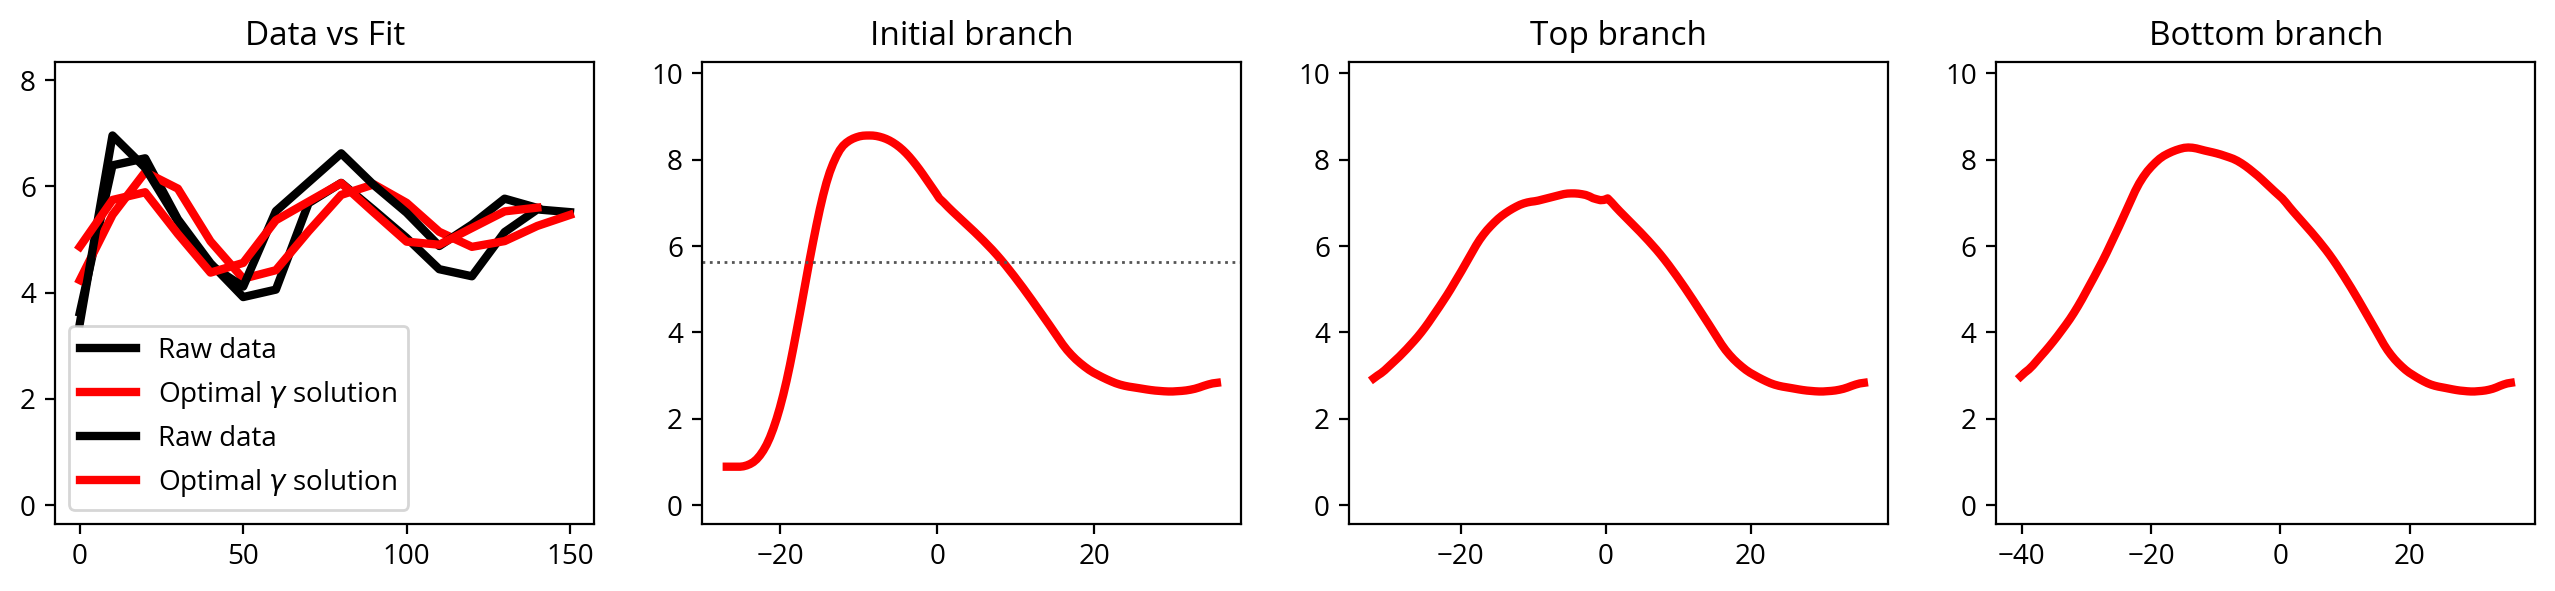

In [575]:
kappa = 0.001
eta = 1
expression_deconv_runner.deconvolve_gene_optimal_gamma('CLB5', kappa=kappa, eta=eta)
clb5_tx_F = expression_deconv_runner.retrieve_solution()
expression_deconv_runner.plot_solution()

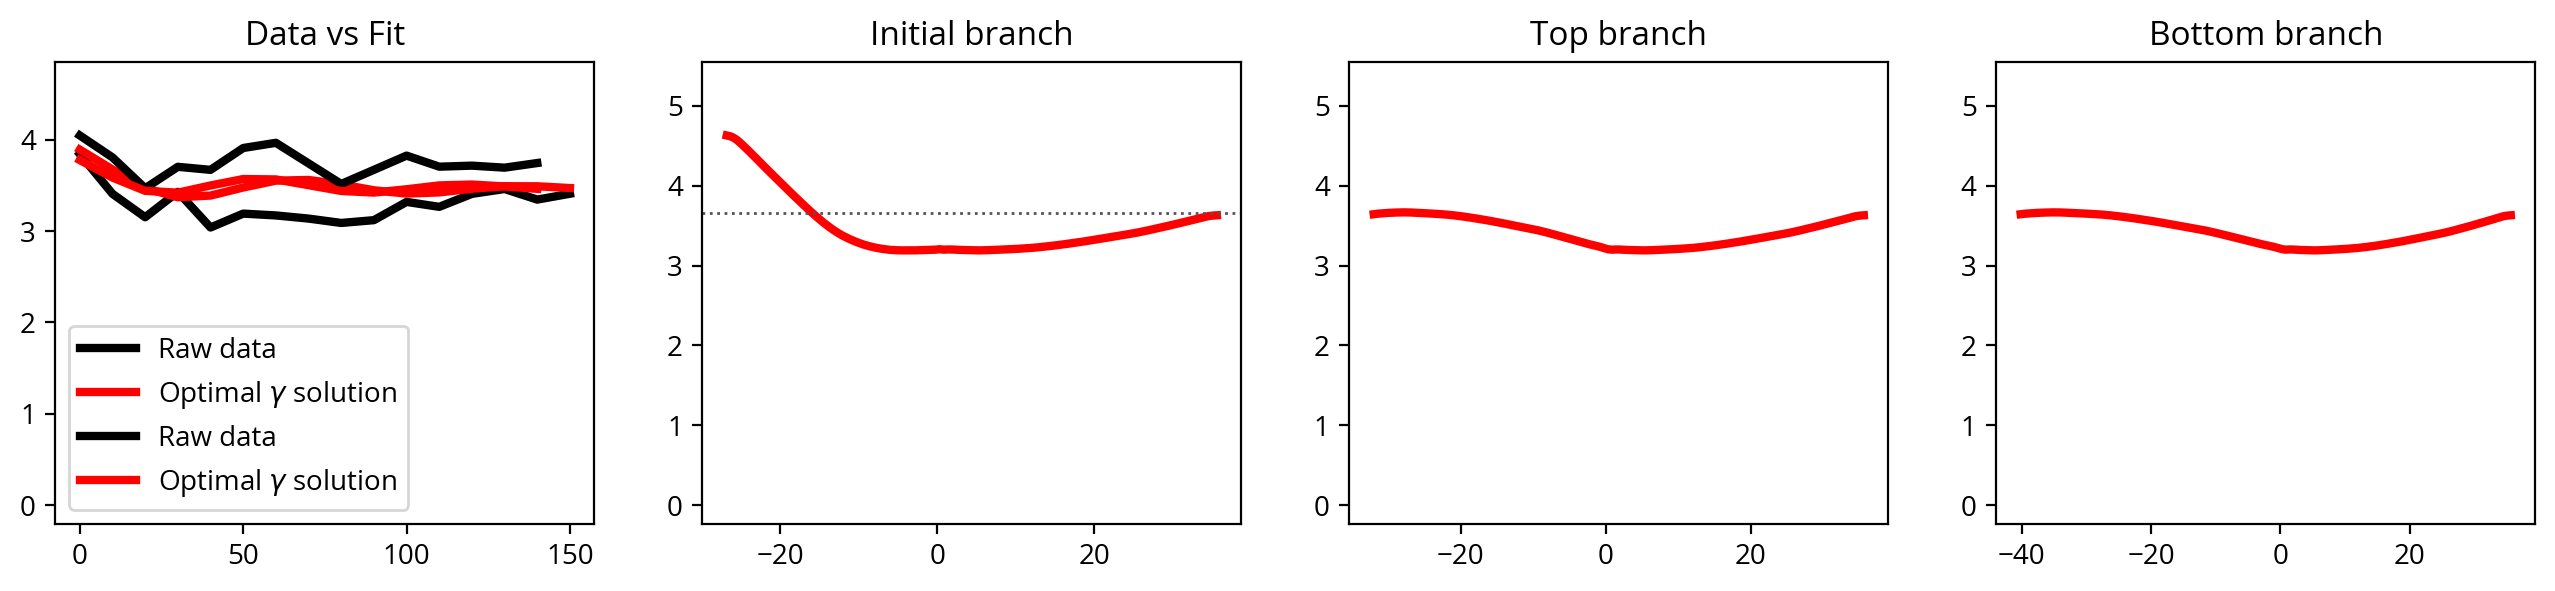

In [576]:
expression_deconv_runner.deconvolve_gene_optimal_gamma('THI22', kappa=kappa, eta=eta)
clb5_tx_F = expression_deconv_runner.retrieve_solution()
expression_deconv_runner.plot_solution()

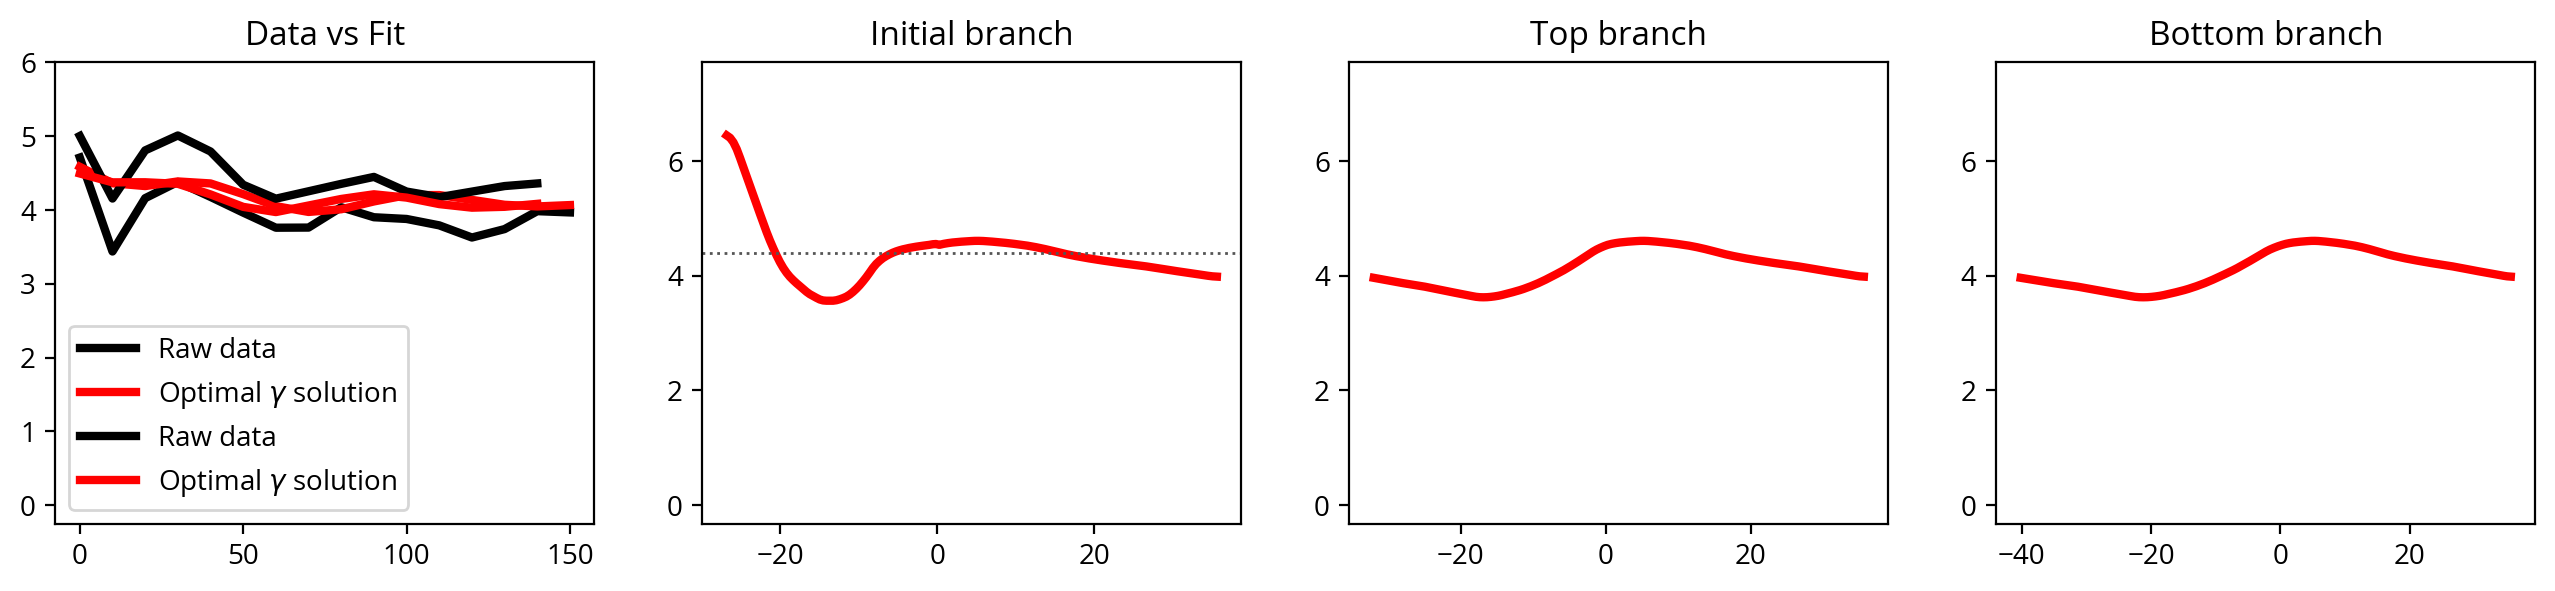

In [577]:
expression_deconv_runner.deconvolve_gene_optimal_gamma('SSK22', kappa=kappa, eta=eta)
clb5_tx_F = expression_deconv_runner.retrieve_solution()
expression_deconv_runner.plot_solution()

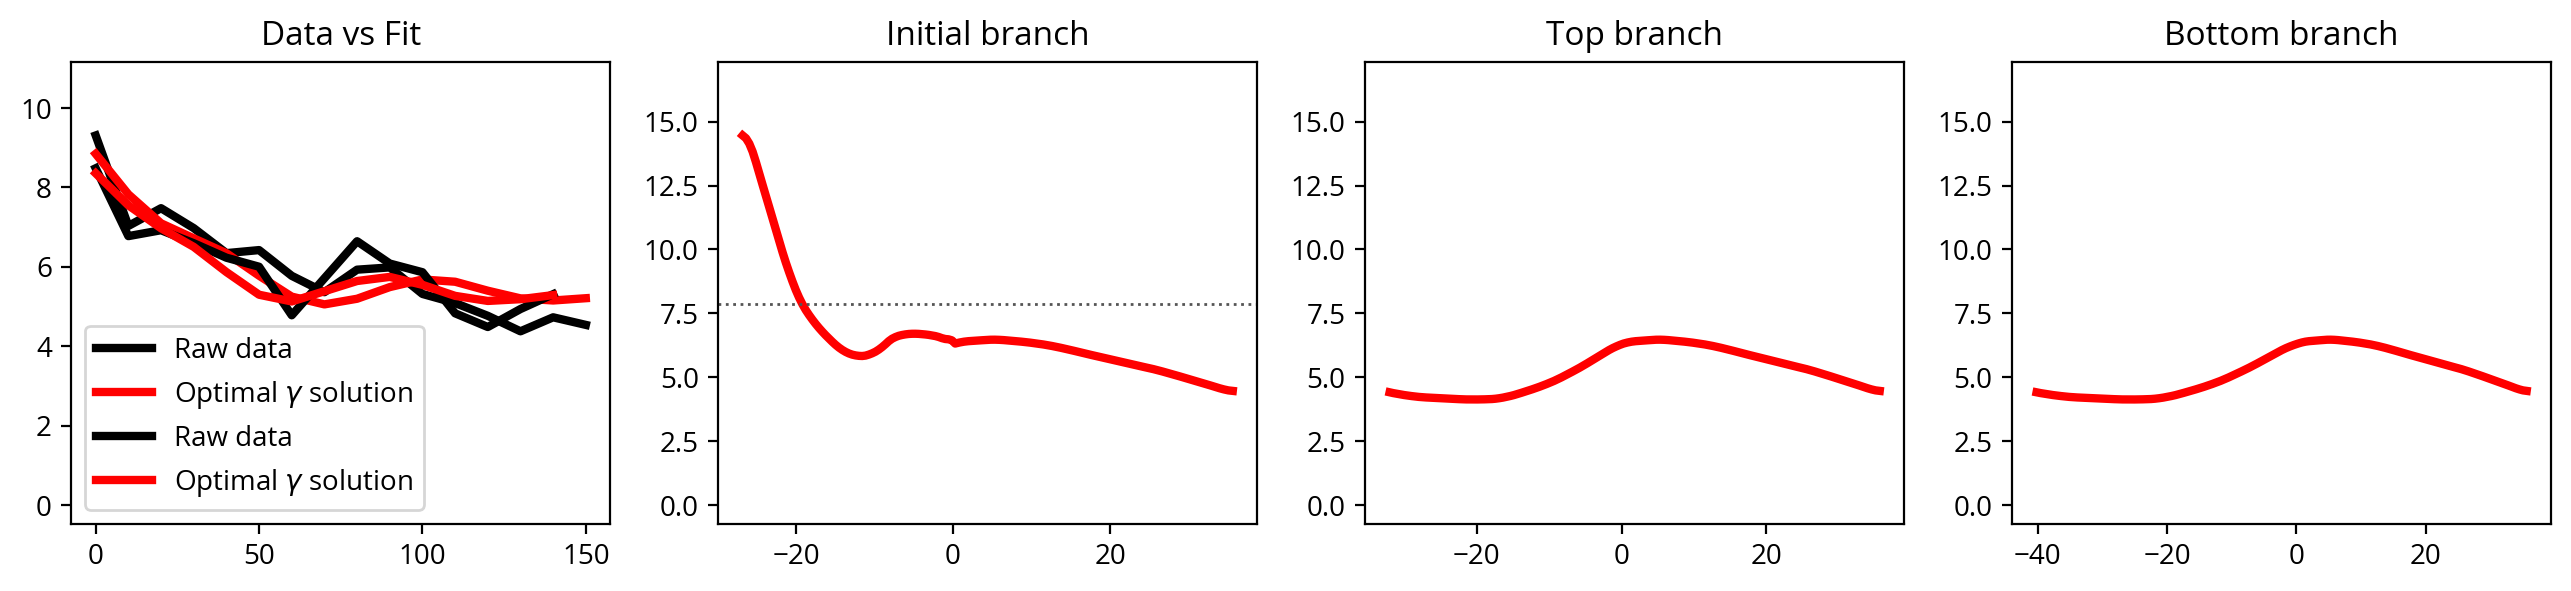

In [578]:
antisense_G_w = np.log2(np.concatenate([normed_selected_reads1_w, normed_selected_reads2_w]))

expression_deconv_runner.deconvolve_G_optimal_gamma(antisense_G_w,
                                                   kappa=kappa, eta=eta)
clb5_antisense_tx_w_F = expression_deconv_runner.retrieve_solution()
expression_deconv_runner.plot_solution()


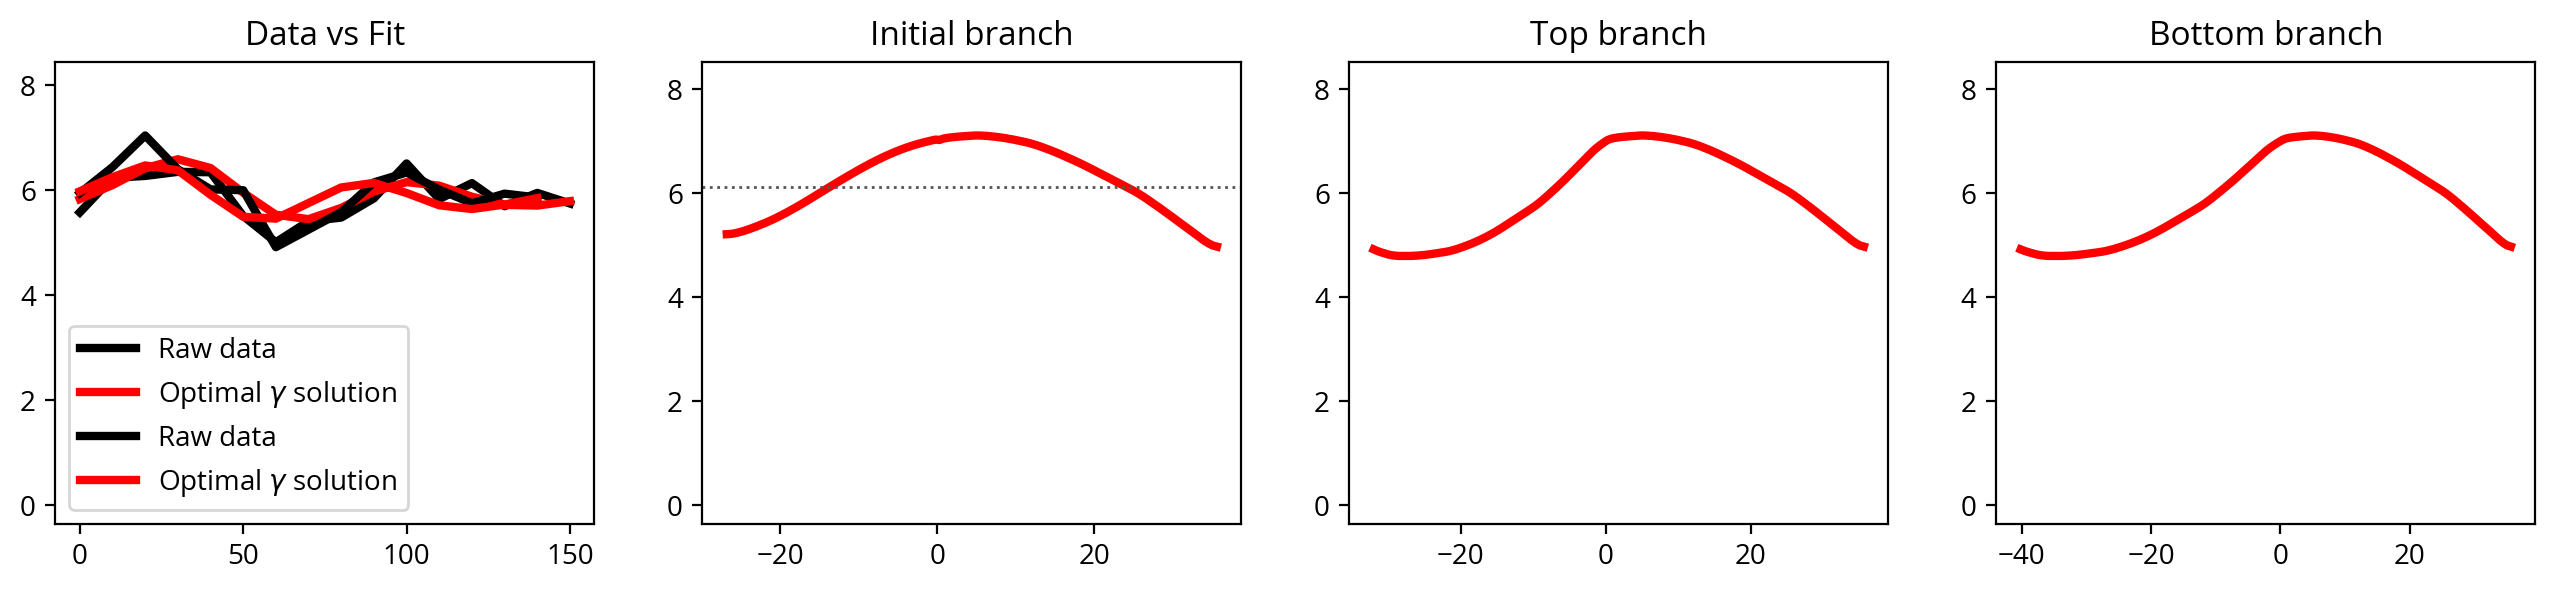

In [579]:
antisense_G_c = np.log2(np.concatenate([normed_selected_reads1_c, normed_selected_reads2_c]))

expression_deconv_runner.deconvolve_G_optimal_gamma(G=antisense_G_c,
                                                   kappa=kappa, eta=eta)
clb5_antisense_tx_c_F = expression_deconv_runner.retrieve_solution()
expression_deconv_runner.plot_solution()


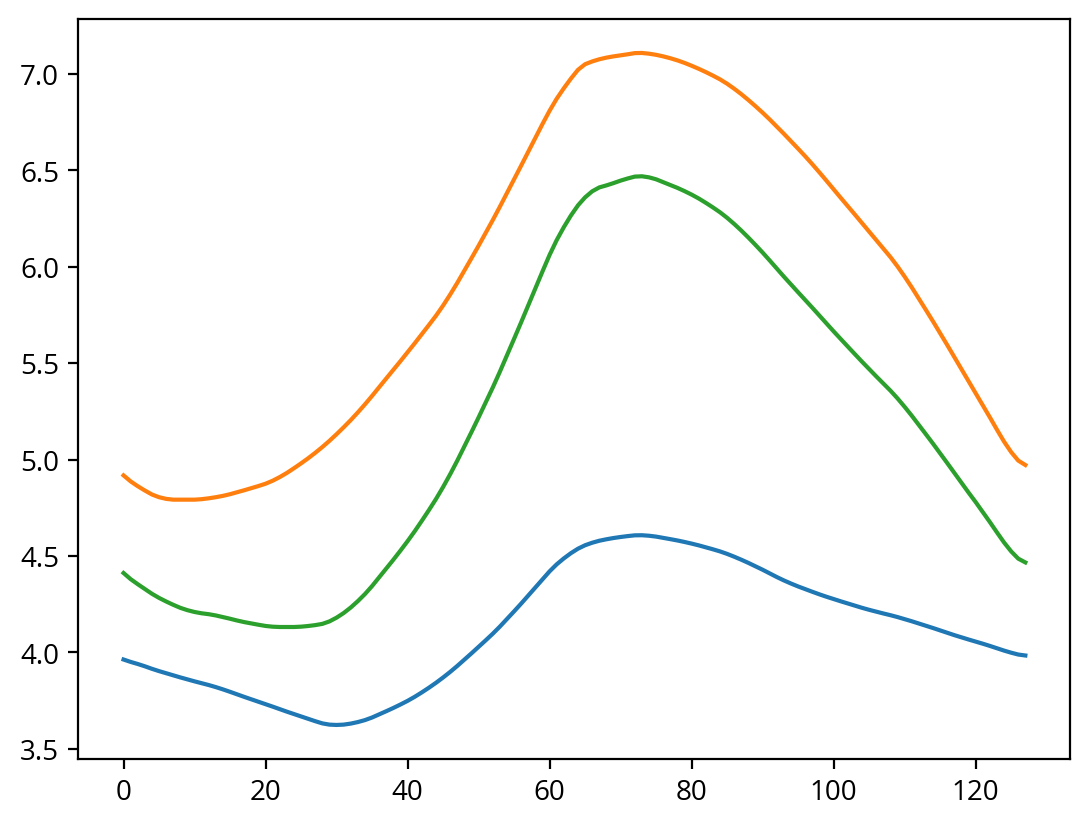

In [580]:
plt.plot(clb5_tx_F[config.t_indices()])
plt.plot(clb5_antisense_tx_c_F[config.t_indices()])
plt.plot(clb5_antisense_tx_w_F[config.t_indices()])


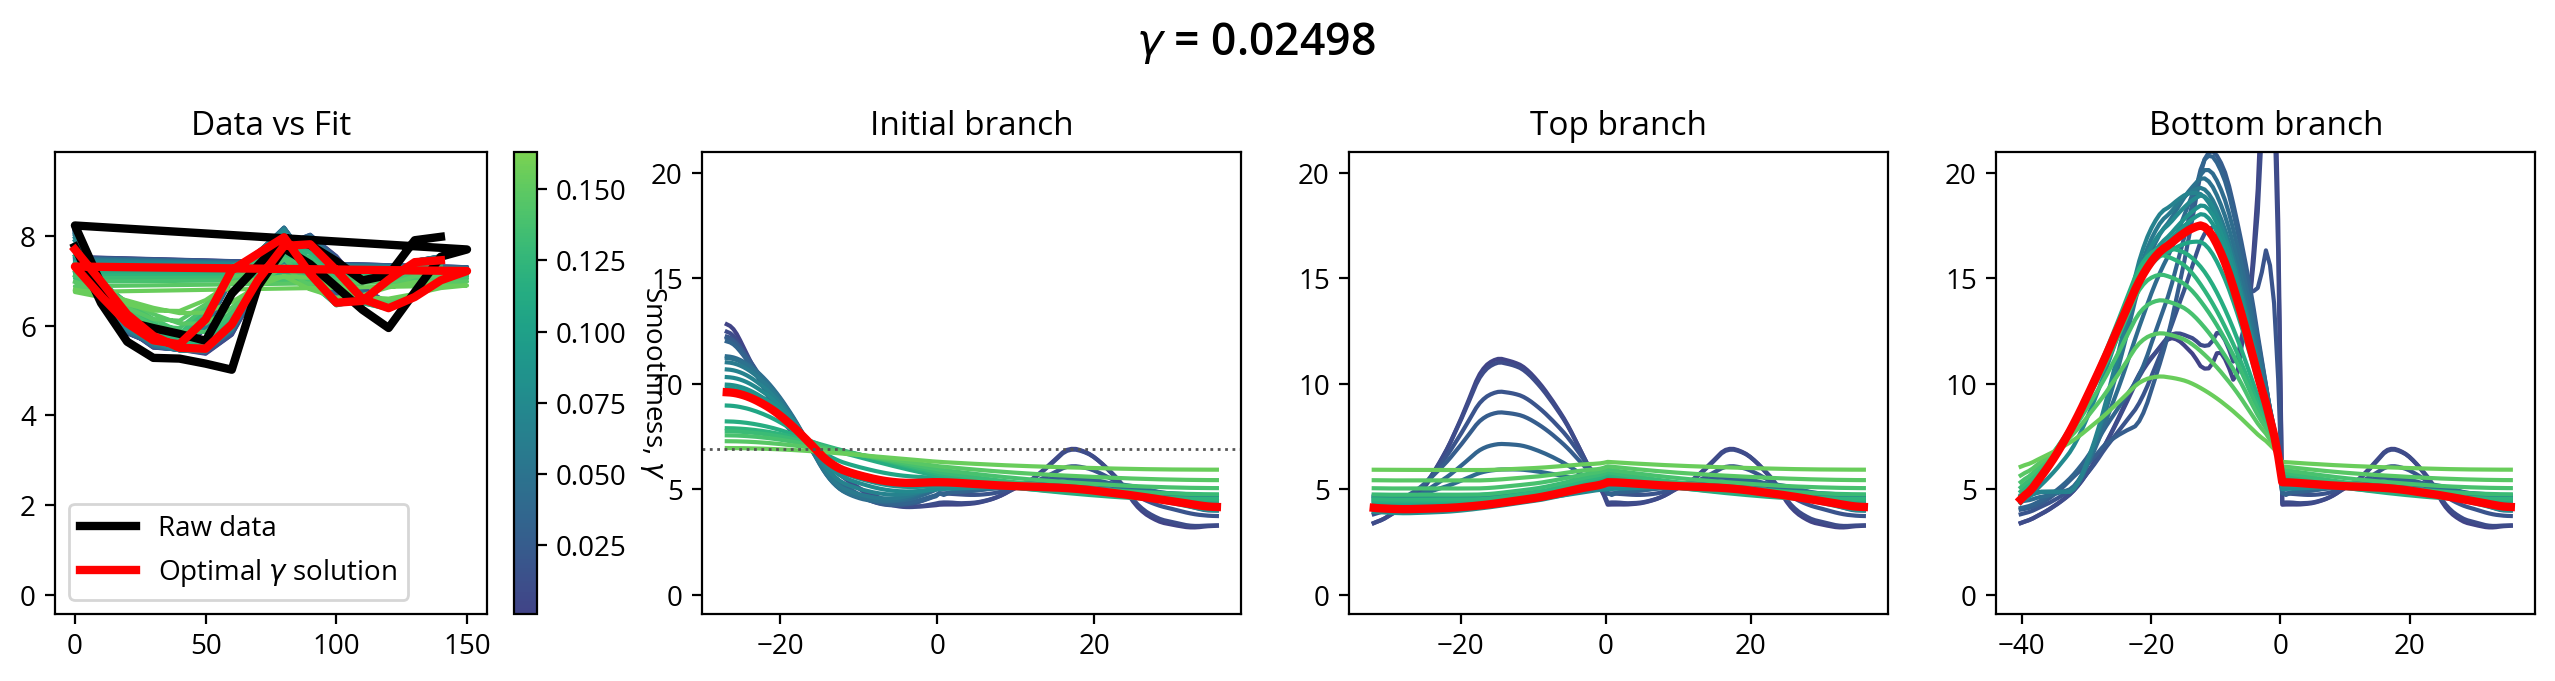

In [583]:
expression_deconv_runner.deconvolve_gene_optimal_gamma('DSE1', kappa=kappa, eta=eta)
fig = expression_deconv_runner.expression_find_gamma.plot_gamma_sweep()